In [1]:
import pandas as pd
import numpy as np

In [2]:
np.random.seed(42)
n = 100000

data = pd.DataFrame({
    "Customer_ID": np.arange(1, n+1),
    "Age": np.random.randint(18, 71, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Tenure": np.random.randint(0, 11, n),
    "Balance": np.random.randint(0, 200001, n),
    "CreditScore": np.random.randint(300, 901, n),
    "EstimatedSalary": np.random.randint(10000, 150001, n),
    "NumOfProducts": np.random.randint(1, 5, n),
    "IsActiveMember": np.random.choice(["Yes", "No"], n)
})


data["Churn"] = np.where(
    (data["Balance"] < 50000) &
    (data["IsActiveMember"] == "No") &
    (data["Tenure"] < 3), 1, 0
    )
print(data.head())

   Customer_ID  Age  Gender  Tenure  Balance  CreditScore  EstimatedSalary  \
0            1   56  Female       3   138803          718           121992   
1            2   69    Male       1   174102          534           125877   
2            3   46  Female      10    90135          653            39062   
3            4   32    Male       6   160284          787            66364   
4            5   60  Female       6    24298          681           116045   

   NumOfProducts IsActiveMember  Churn  
0              4             No      0  
1              2             No      0  
2              2            Yes      0  
3              2            Yes      0  
4              2            Yes      0  


In [3]:
print(data.isnull().sum())

Customer_ID        0
Age                0
Gender             0
Tenure             0
Balance            0
CreditScore        0
EstimatedSalary    0
NumOfProducts      0
IsActiveMember     0
Churn              0
dtype: int64


In [4]:
print(data.dtypes)

Customer_ID         int64
Age                 int64
Gender             object
Tenure              int64
Balance             int64
CreditScore         int64
EstimatedSalary     int64
NumOfProducts       int64
IsActiveMember     object
Churn               int64
dtype: object


In [5]:
data.drop_duplicates(inplace=True)

In [6]:
data["Gender"] = data["Gender"].map({"Male": 0, "Female": 1})
data["IsActiveMember"] = data["IsActiveMember"].map({"No": 0, "Yes": 1})


In [7]:
print(data.mean(numeric_only=True))


Customer_ID        50000.50000
Age                   43.98406
Gender                 0.49891
Tenure                 4.98876
Balance            99742.23367
CreditScore          599.94275
EstimatedSalary    79959.02136
NumOfProducts          2.50198
IsActiveMember         0.49893
Churn                  0.03422
dtype: float64


In [8]:
print(data.median(numeric_only=True))

Customer_ID        50000.5
Age                   44.0
Gender                 0.0
Tenure                 5.0
Balance            99729.0
CreditScore          599.0
EstimatedSalary    80008.5
NumOfProducts          3.0
IsActiveMember         0.0
Churn                  0.0
dtype: float64


In [9]:
print(data.mode().iloc[0])

Customer_ID            1.0
Age                   40.0
Gender                 0.0
Tenure                 4.0
Balance            67150.0
CreditScore          521.0
EstimatedSalary    11429.0
NumOfProducts          3.0
IsActiveMember         0.0
Churn                  0.0
Name: 0, dtype: float64


In [10]:
print(data.std(numeric_only=True))

Customer_ID        28867.657797
Age                   15.251827
Gender                 0.500001
Tenure                 3.163744
Balance            57670.541911
CreditScore          173.269555
EstimatedSalary    40445.277417
NumOfProducts          1.117734
IsActiveMember         0.500001
Churn                  0.181795
dtype: float64


In [11]:
high_churn = data[data["Churn"] == 1]
low_churn = data[data["Churn"] == 0]

print("High Churn Count:", len(high_churn))
print("Low Churn Count:", len(low_churn))

High Churn Count: 3422
Low Churn Count: 96578


In [12]:
print(data.groupby("Churn").mean(numeric_only=True))

        Customer_ID        Age    Gender    Tenure        Balance  \
Churn                                                               
0      49992.281296  43.992390  0.498468  5.130817  102383.608016   
1      50232.453828  43.748977  0.511397  0.979544   25195.579193   

       CreditScore  EstimatedSalary  NumOfProducts  IsActiveMember  
Churn                                                               
0       600.023401     79990.691379       2.501543        0.516608  
1       597.666569     79065.208650       2.514319        0.000000  


In [13]:
data["AgeGroup"] = pd.cut(data["Age"],
                         bins=[18,30,40,50,60,70],
                         labels=["18-30","31-40","41-50","51-60","61-70"])

print(data.groupby("AgeGroup")["Churn"].mean())

AgeGroup
18-30    0.035025
31-40    0.034620
41-50    0.033001
51-60    0.035334
61-70    0.033080
Name: Churn, dtype: float64


/tmp/ipykernel_4347/148227122.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(data.groupby("AgeGroup")["Churn"].mean())


In [16]:
print(data.groupby("Gender")["Churn"].mean())

Gender
0    0.033367
1    0.035076
Name: Churn, dtype: float64


In [15]:
print(data.groupby("IsActiveMember")["Churn"].mean())

IsActiveMember
0    0.068294
1    0.000000
Name: Churn, dtype: float64


In [17]:
print(data.groupby("NumOfProducts")["Churn"].mean())


NumOfProducts
1    0.033805
2    0.034179
3    0.033856
4    0.035039
Name: Churn, dtype: float64


In [18]:
print(data.groupby("Churn")["Balance"].mean())

Churn
0    102383.608016
1     25195.579193
Name: Balance, dtype: float64


In [19]:
print(data.groupby("Churn")["CreditScore"].mean())

Churn
0    600.023401
1    597.666569
Name: CreditScore, dtype: float64


In [20]:
print(data.groupby("Churn")["Tenure"].mean())

Churn
0    5.130817
1    0.979544
Name: Tenure, dtype: float64


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

Bar chart

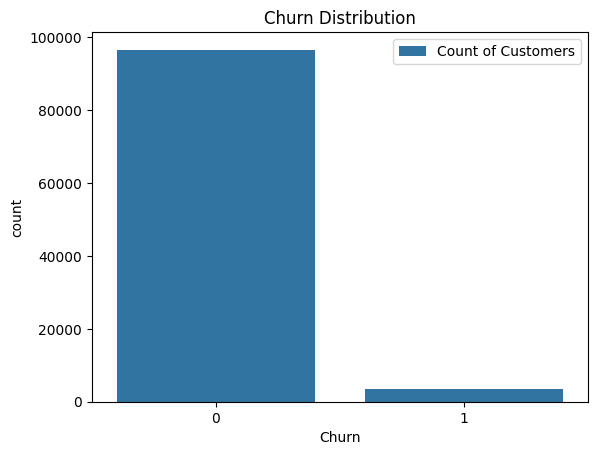

In [22]:
sns.countplot(x="Churn", data=data)

plt.title("Churn Distribution")
plt.legend(["Count of Customers"])
plt.show()


Pie chart

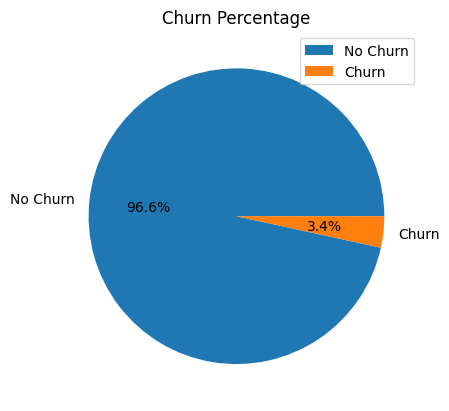

In [23]:
data["Churn"].value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=["No Churn", "Churn"]
)

plt.title("Churn Percentage")
plt.legend(["No Churn", "Churn"], loc="upper right")
plt.ylabel("")
plt.show()


Histogram

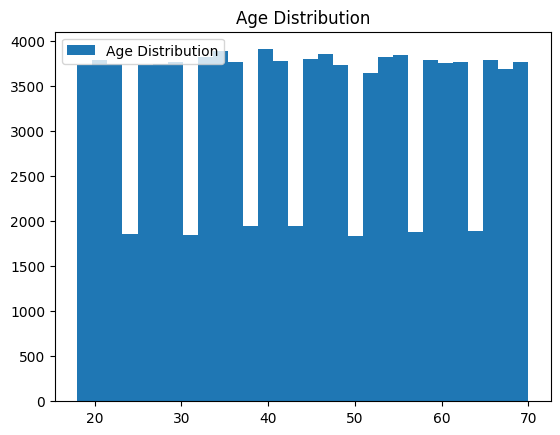

In [24]:
plt.hist(data["Age"], bins=30, label="Age Distribution")

plt.title("Age Distribution")
plt.legend()
plt.show()

Scatter Plot

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


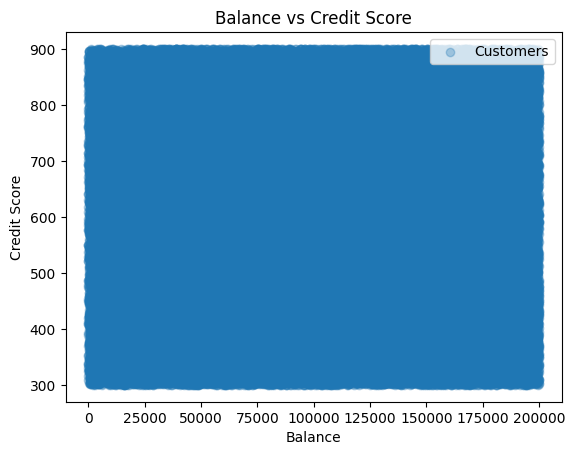

In [25]:
plt.scatter(data["Balance"], data["CreditScore"], alpha=0.3, label="Customers")

plt.xlabel("Balance")
plt.ylabel("Credit Score")
plt.title("Balance vs Credit Score")
plt.legend()
plt.show()


Box Plot

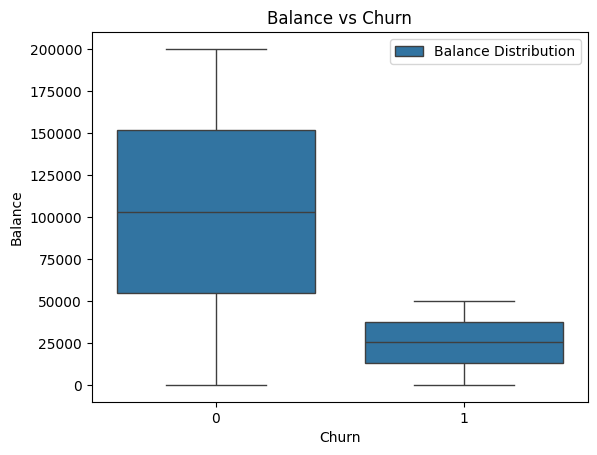

In [26]:
sns.boxplot(x="Churn", y="Balance", data=data)

plt.title("Balance vs Churn")
plt.legend(["Balance Distribution"])
plt.show()



Heatmap

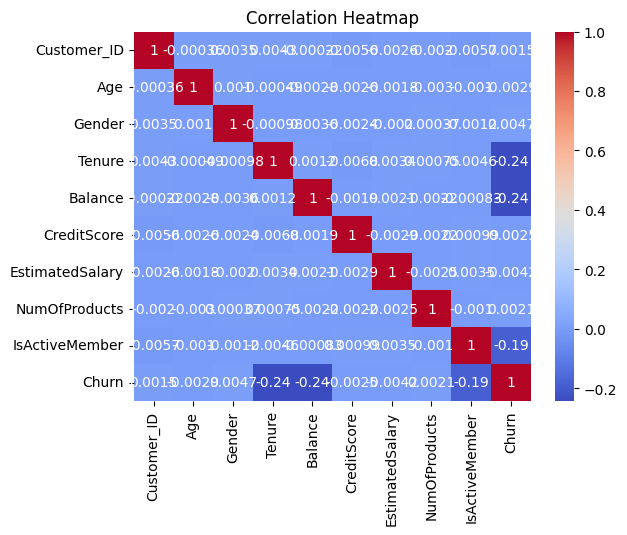

In [27]:
heatmap = sns.heatmap(data.drop('AgeGroup', axis=1).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Insights & Conclusion:

In [28]:
print("Key Insights:")
print("1. Low balance + inactive customers → high churn")
print("2. Low tenure customers churn more")
print("3. Fewer products → higher churn")
print("4. Active users → lower churn")

Key Insights:
1. Low balance + inactive customers → high churn
2. Low tenure customers churn more
3. Fewer products → higher churn
4. Active users → lower churn
